# Stochastic IDS — Full Experiment Notebook

This notebook runs the complete integrated stochastic IDS pipeline from the paper:
*"Stochastic Models for Cyber Attack Detection and Response: A Mathematical Approach to Intrusion Detection Systems"*

    Realised by: 
       HIMEUR IDRIS     SIQ1
       DIAR ADEM        SIQ1

## Architecture
```
Raw Flow Record
       ↓
Preprocessing
       ↓
Markov Chain State-Sequence Modeling
       ↓
Statistical + Queue-Based Anomaly Detection
       ↓
Bayesian Signature Probability Estimation
       ↓
Logistic Regression Fusion Layer
       ↓
Bayesian Parameter Updating
       ↓
Stochastic Optimization (periodic global tuning)
       ↓
Final Detection Output
```

In [2]:
import sys, os
sys.path.insert(0, '../src')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
matplotlib.rcParams['figure.dpi'] = 120

from preprocess  import Preprocessor
from markov      import MarkovChainModel
from anomaly     import StatisticalAnomalyModel
from bayesian    import BayesianSignatureModel
from classifier  import LogisticRegressionFusion, build_fusion_features
from optimizer   import StochasticOptimizer, OptParams
from evaluate    import compute_metrics, compare_before_after

LR_EPOCHS    = 150
VAL_FRACTION = 0.15
OPT_N_ITER   = 300

print('All modules imported successfully.')


All modules imported successfully.


## 1. Dataset and Problem Definition

We work on the **UNSW-NB15** flow-based intrusion detection dataset. Each record represents a network flow described by features such as:

- **Categorical:** `proto`, `service`, `state`
- **Traffic statistics:** `spkts`, `dpkts`, `sbytes`, `dbytes`, `rate`, etc.
- **Derived counters:** `ct_srv_src`, `ct_dst_ltm`, etc.
- **Binary flags:** `is_ftp_login`, `is_sm_ips_ports`
- **Target:** $y_i \in \{0,1\}$ (normal vs attack)

This is a **binary classification problem**. The attack rate is:

$$
p = \frac{1}{N} \sum_{i=1}^{N} y_i
$$

Training and test sets are predefined and must remain separated.

In [3]:
TRAIN_PATH = '../data/UNSW_NB15_training-set.csv'
TEST_PATH  = '../data/UNSW_NB15_testing-set.csv'

df_train = pd.read_csv(TRAIN_PATH, low_memory=False)
df_test  = pd.read_csv(TEST_PATH,  low_memory=False)
df_train.columns = [c.strip() for c in df_train.columns]
df_test.columns  = [c.strip() for c in df_test.columns]

print(f'Train: {df_train.shape}   Attack rate: {df_train.label.mean():.3f}')
print(f'Test:  {df_test.shape}    Attack rate: {df_test.label.mean():.3f}')
df_train.head(3)

Train: (175341, 45)   Attack rate: 0.681
Test:  (82332, 45)    Attack rate: 0.551


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0


## 2. Preprocessing (Module 1)

Three transformations are applied sequentially:

**Missing values** — Numeric features are imputed using the median ($x_j \leftarrow \text{median}(x_j)$); categorical features are filled with `"unknown"`.

**One-hot encoding** — Categorical features (`proto`, `service`, `state`) are expanded into binary indicator vectors:

$$x_{\text{cat}} \rightarrow (0,1)^k$$

**Standardization** — All numeric features are z-scored using training statistics only:

$$x' = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}$$

This ensures comparable feature scales and stable gradient descent. The scaler is fitted on training data and applied unchanged to test data.

In [4]:
preprocessor = Preprocessor()
df_train_proc = preprocessor.fit_transform(df_train)
df_test_proc  = preprocessor.transform(df_test)

X_train, y_train = preprocessor.get_X_y(df_train_proc)
X_test,  y_test  = preprocessor.get_X_y(df_test_proc)

p_train = float(y_train.mean())
p_test  = float(y_test.mean())

print(f'X_train shape: {X_train.shape}')
print(f'X_test  shape: {X_test.shape}')
print(f'Train attack rate: {p_train:.3f}  |  Test attack rate: {p_test:.3f}')


X_train shape: (175341, 195)
X_test  shape: (82332, 195)
Train attack rate: 0.681  |  Test attack rate: 0.551


## 3. Markov Chain State Modeling (Module 2)

Each flow is mapped to a discrete state $St = (\text{proto}, \text{state})$ and we assume a first-order Markov process: $P(S{t+1} \mid St)$.

Transition probabilities are estimated from count matrices with Laplace smoothing:

$$
P_{ij} = \frac{C_{ij} + \alpha}{\sum_{k} C_{ik} + \alpha n}
$$

where $C_{ij}$ is the count of transitions from state $i$ to $j$, $\alpha$ is the smoothing parameter, and $n$ is the number of possible states.

The anomaly score for each transition is 
$$
A_t =
-
\left(
0.5 \log P(S_t)
+
0.5 \log P(S_t \mid S_{t-1})
\right)
$$

Markov score — mean: 0.4766, std: 0.1789


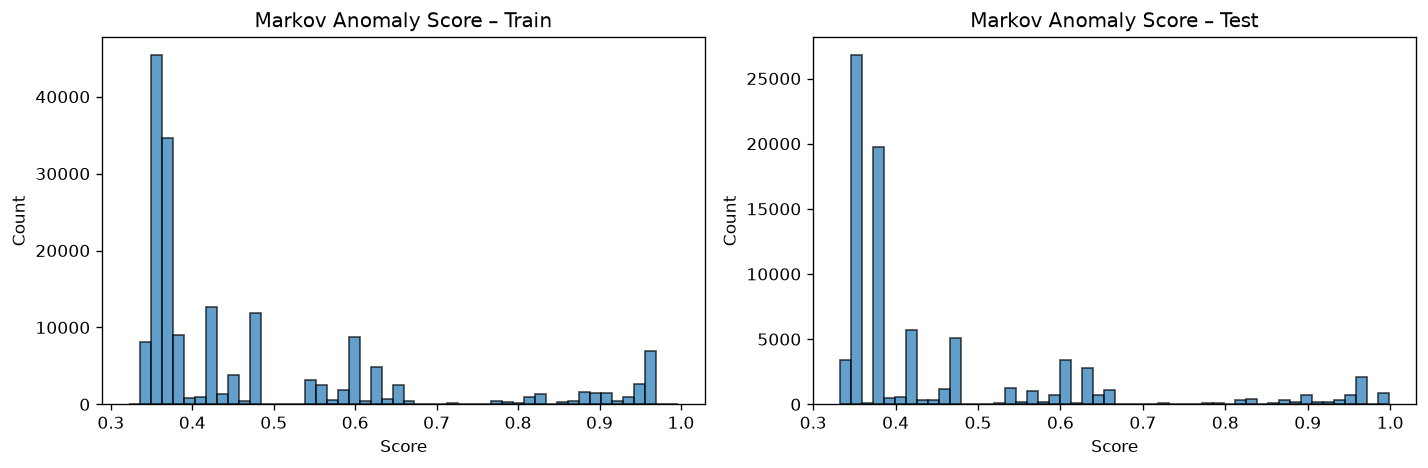

In [5]:
markov = MarkovChainModel(smoothing=1e-4, anomaly_percentile=10.0)
markov.fit(df_train)

markov_train = markov.score(df_train)
markov_test  = markov.score(df_test)

print(f'Markov score — mean: {markov_train.mean():.4f}, std: {markov_train.std():.4f}')

# Plot score distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, scores, lbl in zip(axes, [markov_train, markov_test], ['Train', 'Test']):
    ax.hist(scores, bins=50, edgecolor='k', alpha=0.7)
    ax.set_title(f'Markov Anomaly Score – {lbl}')
    ax.set_xlabel('Score'); ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../notebooks/markov_scores.png')
plt.show()


## 4. Statistical + Queue-Based Anomaly Detection (Module 3)

M/M/1 queue approximation — For each flow, arrival ($\lambda$) and service ($\mu$) rates are estimated from packet counts and duration:

$$\lambda = \frac{\text{spkts}}{\text{dur}}, \quad \mu = \frac{\text{dpkts}}{\text{dur}}, \quad \rho = \frac{\lambda}{\mu}, \quad L = \frac{\rho}{1-\rho}$$

Here, $L$ represents the expected number of flows (or jobs) in the system, indicating congestion intensity for that flow.

This approximates per-flow congestion intensity.

Gaussian density modeling — Continuous features are modeled as Gaussian:

$$f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

The log-likelihood anomaly score is derived and normalized to $[0,1]$.

Note: Queue modeling is a per-flow approximation, meaning each flow is analyzed independently as its own queue, rather than modeling the entire network as a single, global queueing process.

    [StatModel] Fitted 21 features: ['spkts', 'dpkts', 'sload', 'dload', 'sbytes', 'dbytes', 'dur', 'sinpkt', 'dinpkt', 'tcprtt', 'synack', 'ackdat', 'sjit', 'djit', 'sttl', 'dttl', 'smean', 'dmean', 'rate', 'ct_srv_src', 'ct_srv_dst']
Stat score — mean: 0.5225, std: 0.0982


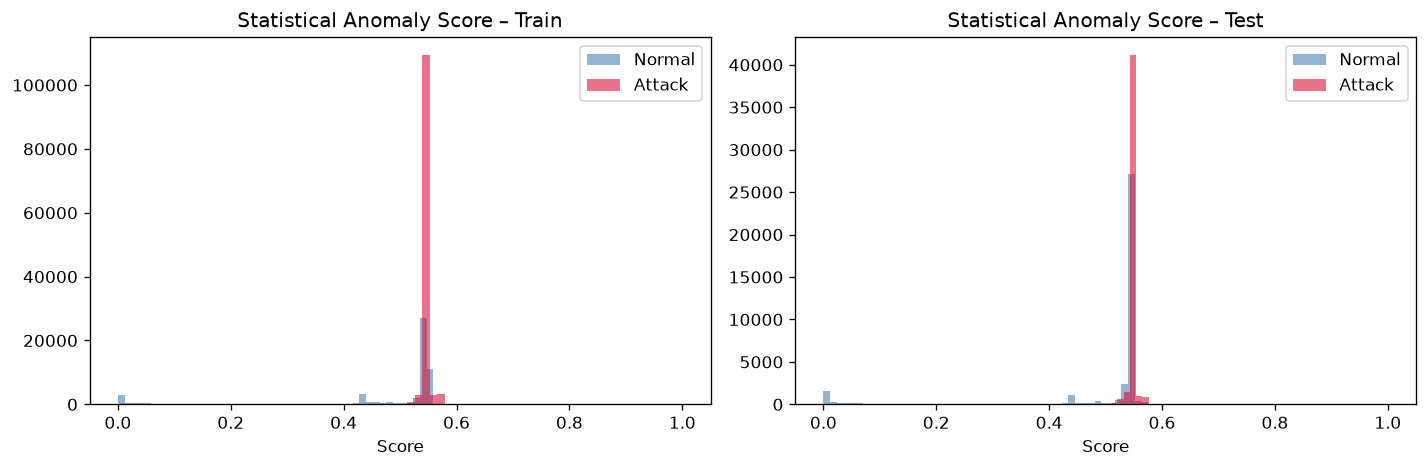

In [6]:
stat_model = StatisticalAnomalyModel(contamination=0.15)
stat_model.fit(df_train, y_train)

stat_train = stat_model.score(df_train)
stat_test  = stat_model.score(df_test)

print(f'Stat score — mean: {stat_train.mean():.4f}, std: {stat_train.std():.4f}')

# Compare normal vs attack distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, scores, labels, title in [
    (axes[0], stat_train, y_train, 'Train'),
    (axes[1], stat_test,  y_test,  'Test'),
]:
    ax.hist(scores[labels == 0], bins=50, alpha=0.6, label='Normal',  color='steelblue')
    ax.hist(scores[labels == 1], bins=50, alpha=0.6, label='Attack',  color='crimson')
    ax.set_title(f'Statistical Anomaly Score – {title}')
    ax.set_xlabel('Score'); ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/stat_scores.png')
plt.show()


## 5. Bayesian Signature Matching (Module 4)

Uses **Bayes' theorem** with a naïve independence assumption to estimate the posterior attack probability for each flow:

$$P(A \mid X) = \frac{P(X \mid A)\,P(A)}{P(X)}, \qquad P(X \mid A) = \prod_j P(x_j \mid A)$$

where:

- $A$ — Attack class ($1$ for attack, $0$ for normal)
- $X$ — Feature vector for a flow
- $P(A)$ — Prior probability of attack (estimated from training data)
- $P(X \mid A)$ — Likelihood of observing features $X$ given class $A$ (product of per-feature probabilities)
- $P(x_j \mid A)$ — Probability of feature $j$ taking its observed value, given class $A$ (estimated from counts with smoothing)
- $\alpha$ — Smoothing parameter to avoid zero probabilities
- $N$ — Number of samples in class $A$
- $K$ — Number of possible values for feature $j$

Feature likelihoods are estimated from training data with **Laplace smoothing**:

$$P(x_j = v \mid A) = \frac{\text{count} + \alpha}{N + \alpha\, K}$$

Log-domain computation is used for numerical stability. The output score is:

$$s_{\text{bayes}} = P(\text{attack} \mid X)$$

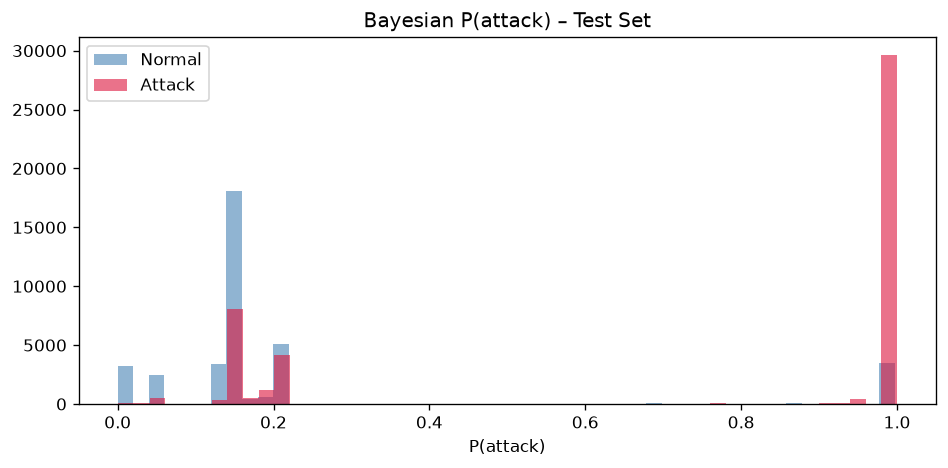

In [7]:
bayes_model = BayesianSignatureModel(smoothing=1.0)
bayes_model.fit(df_train, y_train)

bayes_train = bayes_model.score(df_train)
bayes_test  = bayes_model.score(df_test)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(bayes_test[y_test == 0], bins=50, alpha=0.6, label='Normal', color='steelblue')
ax.hist(bayes_test[y_test == 1], bins=50, alpha=0.6, label='Attack', color='crimson')
ax.set_title('Bayesian P(attack) – Test Set')
ax.set_xlabel('P(attack)'); ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/bayes_scores.png')
plt.show()

## 6. Feature Fusion via Logistic Regression (Module 5) + Bayesian Update (Module 6)

### 6.1 Feature Stacking

The three probabilistic scores are appended to the base feature matrix:

$$X_{\text{fused}} = [X_{\text{base}},\; s_{\text{markov}},\; s_{\text{stat}},\; s_{\text{bayes}}]$$

### 6.2 Logistic Model

$$P(y=1 \mid X) = \sigma(w^T X + b), \qquad \sigma(z) = \frac{1}{1+e^{-z}}$$

### 6.3 Loss Function

Binary cross-entropy with L2 regularization:

$$\mathcal{L} = -\frac{1}{N}\sum\left[y\log p + (1-y)\log(1-p)\right] + \lambda\|w\|^2$$

Training uses mini-batch gradient descent with class balancing. The validation split is **stratified** to preserve the attack rate.

### 6.4 Bayesian Online Update

After fusion training, the Markov, Statistical, and Bayesian model parameters are updated on the validation set via pseudo-count augmentation:

$$C^{\text{new}} = C^{\text{old}} + \Delta C$$

This mimics incremental Bayesian updating.

Fused feature matrix shape: (175341, 198)
Val split: 26302 samples, attack rate: 0.681
LR training complete. Final loss: 0.2299
Val F1 (threshold=0.5): 0.9481  Acc: 0.9280


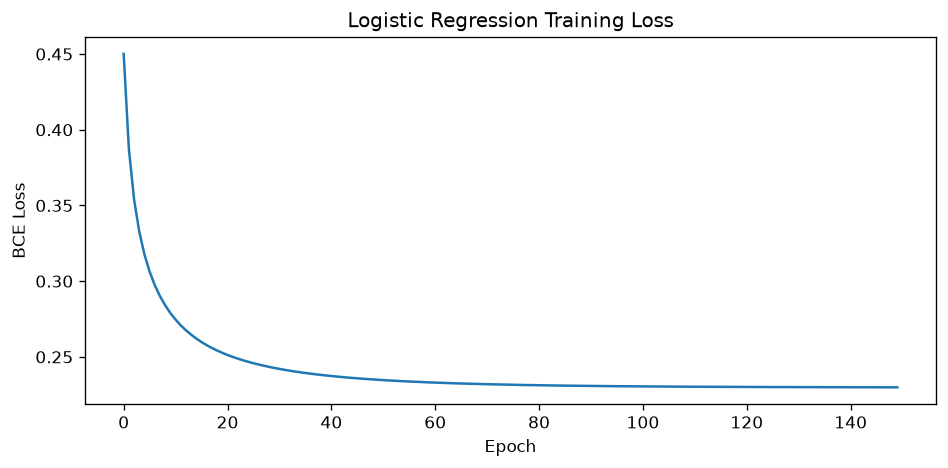

Bayesian parameter update on val set …
Bayesian parameter update complete.

── Validation Set (post Bayesian update, threshold=0.5) ──
  Accuracy : 0.9280
  Precision: 0.9300
  Recall   : 0.9670
  F1       : 0.9481

── Test Set (post Bayesian update, threshold=0.5) ──
  Accuracy : 0.8095
  Precision: 0.7641
  Recall   : 0.9461
  F1       : 0.8454


In [8]:
X_fused_train = build_fusion_features(X_train, markov_train, stat_train, bayes_train)
X_fused_test  = build_fusion_features(X_test,  markov_test,  stat_test,  bayes_test)

print(f'Fused feature matrix shape: {X_fused_train.shape}')

# Stratified validation split (matching train.py)
idx_tr, idx_val = train_test_split(
    np.arange(len(X_train)), test_size=VAL_FRACTION,
    stratify=y_train, random_state=42)

X_tr  = X_fused_train[idx_tr];  y_tr  = y_train[idx_tr]
X_val = X_fused_train[idx_val]; y_val = y_train[idx_val]

p_val = float(y_val.mean())
print(f'Val split: {len(idx_val)} samples, attack rate: {p_val:.3f}')

fusion = LogisticRegressionFusion(
    lr=0.005, n_epochs=LR_EPOCHS, batch_size=1024,
    lambda_reg=0.01, class_weight='balanced')
fusion.fit(X_tr, y_tr)

print(f'LR training complete. Final loss: {fusion.loss_history_[-1]:.4f}')

y_val_pred = fusion.predict(X_val, threshold=0.5)
print(f'Val F1 (threshold=0.5): {f1_score(y_val, y_val_pred, zero_division=0):.4f}  '
      f'Acc: {accuracy_score(y_val, y_val_pred):.4f}')

# Plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(fusion.loss_history_)
plt.title('Logistic Regression Training Loss')
plt.xlabel('Epoch'); plt.ylabel('BCE Loss')
plt.tight_layout()
plt.savefig('../notebooks/lr_loss.png')
plt.show()

# Bayesian parameter update on val set
print('Bayesian parameter update on val set …')
markov.bayesian_update(df_train.iloc[idx_val])
stat_model.bayesian_update(df_train.iloc[idx_val])
bayes_model.bayesian_update(df_train.iloc[idx_val], y_val)
print('Bayesian parameter update complete.')

# ── Post-update metrics on val and test sets ──
from sklearn.metrics import precision_score, recall_score, classification_report

y_val_proba  = fusion.predict_proba(X_val)
y_test_proba = fusion.predict_proba(X_fused_test)

y_val_pred_post  = (y_val_proba  >= 0.5).astype(int)
y_test_pred_post = (y_test_proba >= 0.5).astype(int)

print('\n── Validation Set (post Bayesian update, threshold=0.5) ──')
print(f'  Accuracy : {accuracy_score(y_val, y_val_pred_post):.4f}')
print(f'  Precision: {precision_score(y_val, y_val_pred_post, zero_division=0):.4f}')
print(f'  Recall   : {recall_score(y_val, y_val_pred_post, zero_division=0):.4f}')
print(f'  F1       : {f1_score(y_val, y_val_pred_post, zero_division=0):.4f}')

print('\n── Test Set (post Bayesian update, threshold=0.5) ──')
print(f'  Accuracy : {accuracy_score(y_test, y_test_pred_post):.4f}')
print(f'  Precision: {precision_score(y_test, y_test_pred_post, zero_division=0):.4f}')
print(f'  Recall   : {recall_score(y_test, y_test_pred_post, zero_division=0):.4f}')
print(f'  F1       : {f1_score(y_test, y_test_pred_post, zero_division=0):.4f}')


## 7. Stochastic Global Optimization (Module 7)

The full parameter vector $\theta = (w, b, \text{threshold}, \text{smoothing})$ is globally tuned.

**Random perturbation** with annealing:

$$\theta_{k+1} = \theta_k + \delta_k$$

**Acceptance rule** — greedy hill-climbing:

$$\text{Accept if } f(\theta_{k+1}) \ge f(\theta_k)$$

**Objective function** — F1-score with a false-positive penalty:

$$f = F_1 - \alpha \cdot \text{FP\_rate}$$

The threshold is biased downward to compensate for the **prior distribution shift** between the validation set (higher attack rate) and the test set (lower attack rate).

Val attack rate: 0.681  (test attack rate is NOT used to steer the search)
Objective BEFORE optimization: 0.9016
Objective AFTER  optimization: 0.9090
Improvement:                   +0.0074
Optimal threshold: 0.5737


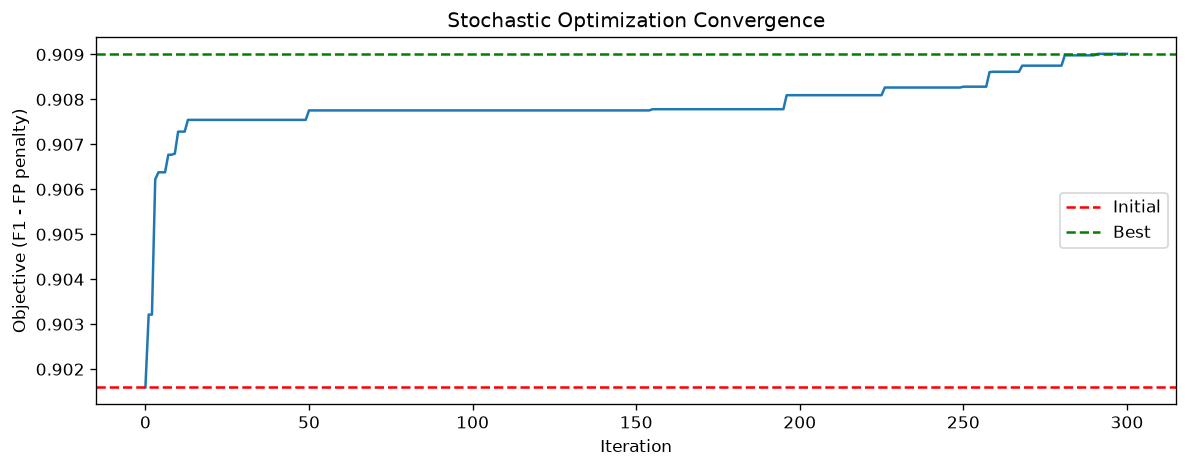

In [9]:
print(f'Val attack rate: {p_val:.3f}  (test attack rate is NOT used to steer the search)')

init_params = OptParams(
    lr_weights     = fusion.weights_.copy(),
    lr_bias        = fusion.bias_,
    threshold      = 0.5,
    stat_threshold = float(stat_model._threshold or 0.5),
    bayes_smooth   = 1.0,
    markov_smooth  = 1e-4,
)

# NOTE: threshold search must only use validation data (X_val/y_val).
# We do NOT use p_test here anymore -- doing so was data leakage from
# the evaluation target. The optimizer explores both directions.
optimizer = StochasticOptimizer(
    n_iter=OPT_N_ITER,
    sigma_init=0.005,
    sigma_thresh=0.04,
    decay=0.997,
    fp_weight=0.3,
    random_seed=42,
)
best_params = optimizer.optimize(fusion, X_val, y_val, init_params)

conv = optimizer.convergence_summary()
print(f"Objective BEFORE optimization: {conv['initial_obj']:.4f}")
print(f"Objective AFTER  optimization: {conv['best_obj']:.4f}")
print(f"Improvement:                   {conv['improvement']:+.4f}")
print(f"Optimal threshold: {best_params.threshold:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(optimizer.obj_history_)
plt.title('Stochastic Optimization Convergence')
plt.xlabel('Iteration'); plt.ylabel('Objective (F1 - FP penalty)')
plt.axhline(conv['initial_obj'], color='red', ls='--', label='Initial')
plt.axhline(conv['best_obj'],    color='green', ls='--', label='Best')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/optimization_convergence.png')
plt.show()


## Save Models

In [10]:
MODEL_DIR = '../models'
os.makedirs(MODEL_DIR, exist_ok=True)

def save_model(obj, name):
    path = os.path.join(MODEL_DIR, f'{name}.pkl')
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f'  Saved → {path}')

components = {
    'preprocessor' : preprocessor,
    'markov'       : markov,
    'stat_model'   : stat_model,
    'bayes_model'  : bayes_model,
    'fusion'       : fusion,
    'optimizer'    : optimizer,
    'best_params'  : best_params,
    'opt_threshold': best_params.threshold,
    'feature_cols' : preprocessor.feature_cols,
    'p_train'      : p_train,
    'p_val'        : p_val,
    'p_test'       : p_test,
}
save_model(components, 'ids_components')
np.save(os.path.join(MODEL_DIR, 'X_test.npy'),  X_fused_test)
np.save(os.path.join(MODEL_DIR, 'y_test.npy'),  y_test)
np.save(os.path.join(MODEL_DIR, 'X_train.npy'), X_fused_train)
np.save(os.path.join(MODEL_DIR, 'y_train.npy'), y_train)
print('All models saved.')


  Saved → ../models/ids_components.pkl
All models saved.


## 8. Final Evaluation — Before vs After Optimization

Evaluation is performed **only on the held-out test set** to estimate generalization.

The confusion matrix:

$$\begin{bmatrix} TN & FP \\ FN & TP \end{bmatrix}$$

Key metrics:

$$\text{Precision} = \frac{TP}{TP+FP}, \qquad \text{Recall} = \frac{TP}{TP+FN}, \qquad F_1 = \frac{2 \cdot P \cdot R}{P + R}$$

We compare performance at the default threshold (0.5) against the stochastically optimized threshold to quantify the improvement gained by global tuning.

![Evaluation](evaluate.png)

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_proba = fusion.predict_proba(X_fused_test)

y_before = (y_proba >= 0.5).astype(int)
y_after  = (y_proba >= best_params.threshold).astype(int)

metrics_before = compute_metrics(y_test, y_before, label='Before Opt')
metrics_after  = compute_metrics(y_test, y_after,  label='After Opt')

compare_before_after(metrics_before, metrics_after)


[Before Opt] Classification Metrics
  ----------------------------------------
  Accuracy  : 0.8057  (80.57%)
  Precision : 0.7576  (75.76%)
  Recall    : 0.9515  (95.15%)
  F1-Score  : 0.8436  (84.36%)
  Confusion Matrix:
[[23201 13799]
 [ 2198 43134]]

[After Opt] Classification Metrics
  ----------------------------------------
  Accuracy  : 0.8297  (82.97%)
  Precision : 0.8098  (80.98%)
  Recall    : 0.9027  (90.27%)
  F1-Score  : 0.8537  (85.37%)
  Confusion Matrix:
[[27390  9610]
 [ 4411 40921]]

BEFORE vs AFTER STOCHASTIC OPTIMIZATION
Metric              Before      After      Delta
--------------------------------------------------
  Accuracy          80.57%     82.97% +    2.40%
  Precision         75.76%     80.98% +    5.22%
  Recall            95.15%     90.27%    -4.88%
  F1                84.36%     85.37% +    1.02%


─── BEFORE Optimization ───
  TP=43,134  FP=13,799  TN=23,201  FN=2,198

─── AFTER Optimization ───
  TP=40,921  FP=9,610  TN=27,390  FN=4,411


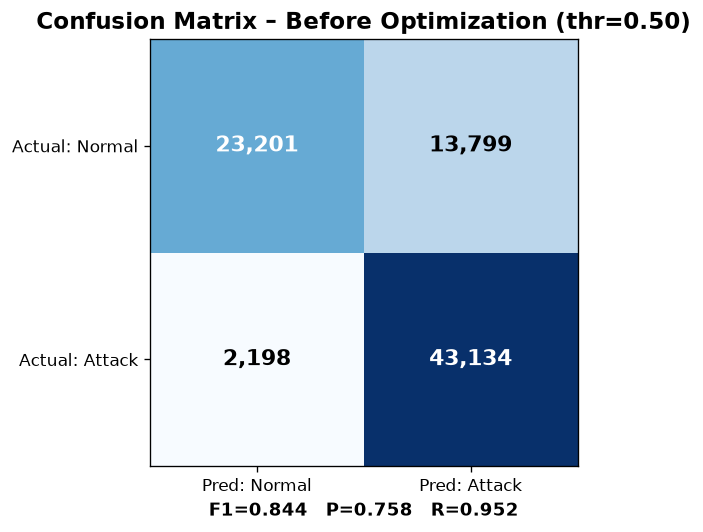

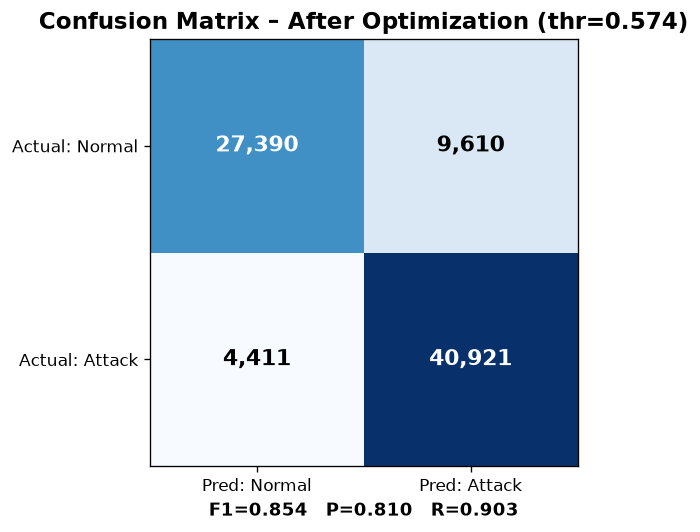

In [12]:

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def plot_cm(cm, title, f1, precision, recall):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(cm, cmap='Blues')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred: Normal', 'Pred: Attack'])
    ax.set_yticklabels(['Actual: Normal', 'Actual: Attack'])

    for i in range(2):
        for j in range(2):
            value = cm[i, j]
            color = "white" if value > cm.max() / 2 else "black"
            ax.text(j, i, f'{value:,}',
                    ha="center", va="center",
                    color=color, fontsize=13, fontweight='bold')

    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.xlabel(f'F1={f1:.3f}   P={precision:.3f}   R={recall:.3f}',
               fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ── Compute confusion matrices ──
cm_before = confusion_matrix(y_test, y_before)
cm_after  = confusion_matrix(y_test, y_after)

tn_b, fp_b, fn_b, tp_b = cm_before.ravel()
tn_a, fp_a, fn_a, tp_a = cm_after.ravel()

print('─── BEFORE Optimization ───')
print(f'  TP={tp_b:,}  FP={fp_b:,}  TN={tn_b:,}  FN={fn_b:,}')

print('\n─── AFTER Optimization ───')
print(f'  TP={tp_a:,}  FP={fp_a:,}  TN={tn_a:,}  FN={fn_a:,}')

# ── Plot confusion matrices ──
plot_cm(cm_before, 'Confusion Matrix – Before Optimization (thr=0.50)',
        metrics_before['f1'], metrics_before['precision'], metrics_before['recall'])

plot_cm(cm_after, f'Confusion Matrix – After Optimization (thr={best_params.threshold:.3f})',
        metrics_after['f1'], metrics_after['precision'], metrics_after['recall'])


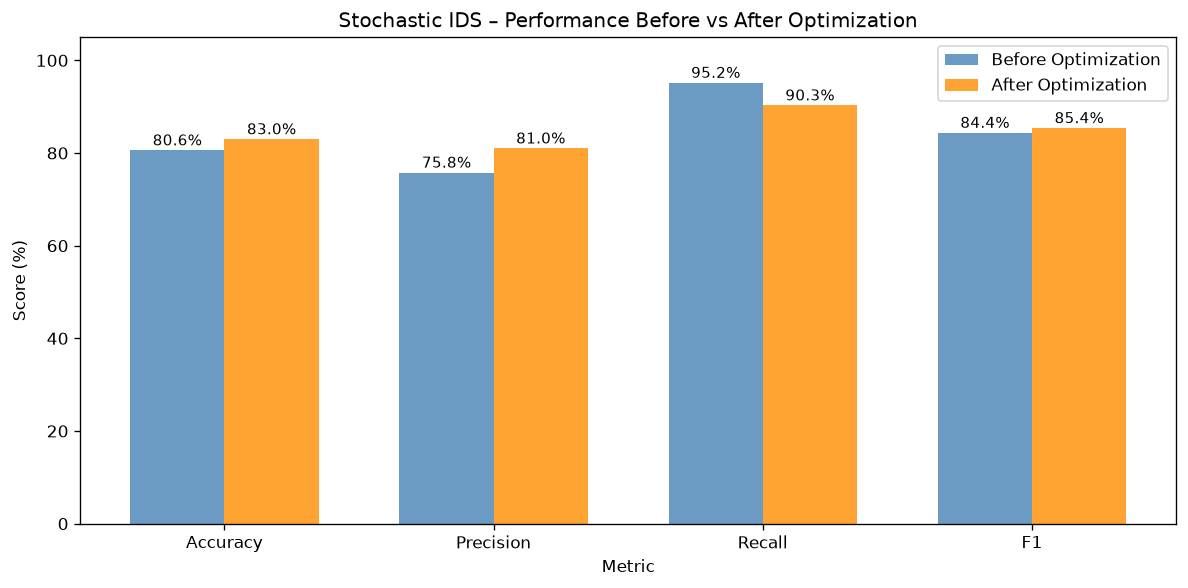

In [13]:
# Summary bar chart
metrics = ['accuracy', 'precision', 'recall', 'f1']
before_vals = [metrics_before[m] * 100 for m in metrics]
after_vals  = [metrics_after[m]  * 100 for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, before_vals, width, label='Before Optimization', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, after_vals,  width, label='After Optimization',  color='darkorange', alpha=0.8)

ax.set_xlabel('Metric')
ax.set_ylabel('Score (%)')
ax.set_title('Stochastic IDS – Performance Before vs After Optimization')
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metrics])
ax.set_ylim(0, 105)
ax.legend()

for bar in bars1:
    ax.annotate(f'{bar.get_height():.1f}%',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.1f}%',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../notebooks/before_after_comparison.png', dpi=150)
plt.show()

## 9. Module Score Weights in Fusion Layer
Shows the relative importance of each probabilistic module.


Fusion weights for the three probabilistic scores:
  markov_score        : +0.1626
  stat_score          : +0.1070
  bayes_score         : +0.3818


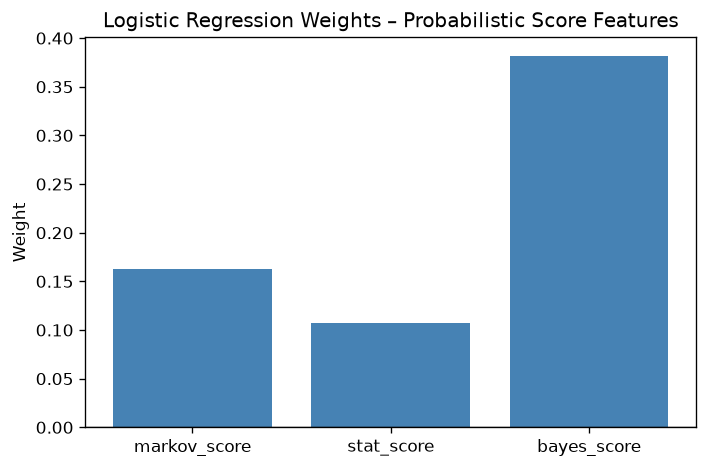

In [14]:
n_raw = X_train.shape[1]
score_names  = ['markov_score', 'stat_score', 'bayes_score']
score_weights = fusion.weights_[-3:]

print('\nFusion weights for the three probabilistic scores:')
for name, w in zip(score_names, score_weights):
    print(f'  {name:20s}: {w:+.4f}')

plt.figure(figsize=(6, 4))
colors = ['steelblue' if w >= 0 else 'crimson' for w in score_weights]
plt.bar(score_names, score_weights, color=colors)
plt.title('Logistic Regression Weights – Probabilistic Score Features')
plt.ylabel('Weight')
plt.axhline(0, color='black', lw=0.8)
plt.tight_layout()
plt.savefig('../notebooks/score_weights.png')
plt.show()